project นี้อ้างอิงมาจาก [linear_regression_assignment_for_students.ipynb](https://colab.research.google.com/drive/1TiEk1nXY-6CD9nOQfmkentShBm9FIFUn?usp=sharing) <br>
เป็นการนำเอาตัวอย่างโค้ดมา amplify เพิ่มเติม ใช้เพื่อการศึกษาในรายวิชา cs372 เท่านั้น

ผู้จัดทำ: กมลพันธ์ กันธายอด 6609520116

In [1]:
# ==========================================
# STEP 0: Import libraries
# ==========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


# ==========================================
# STEP 1: Load Training Data
# ==========================================
url = "https://raw.githubusercontent.com/kamonphankanthayod/ml-regression-predict-forest-fires/refs/heads/main/forestfires.csv"

df = pd.read_csv(url)

print("Raw data shape:", df.shape)
print(df)

Raw data shape: (516, 13)
     X  Y month  day  FFMC    DMC     DC   ISI  temp  RH  wind  rain   area
0    7  5   mar  fri  86.2   26.2   94.3   5.1   8.2  51   6.7   0.0   0.00
1    7  4   oct  tue  90.6   35.4  669.1   6.7  18.0  33   0.9   0.0   0.00
2    7  4   oct  sat  90.6   43.7  686.9   6.7  14.6  33   1.3   0.0   0.00
3    8  6   mar  fri  91.7   33.3   77.5   9.0   8.3  97   4.0   0.2   0.00
4    8  6   mar  sun  89.3   51.3  102.2   9.6  11.4  99   1.8   0.0   0.00
..  .. ..   ...  ...   ...    ...    ...   ...   ...  ..   ...   ...    ...
511  8  6   aug  sun  81.6   56.7  665.6   1.9  27.8  35   2.7   0.0   0.00
512  4  3   aug  sun  81.6   56.7  665.6   1.9  27.8  32   2.7   0.0   6.44
513  2  4   aug  sun  81.6   56.7  665.6   1.9  21.9  71   5.8   0.0  54.29
514  7  4   aug  sun  81.6   56.7  665.6   1.9  21.2  70   6.7   0.0  11.16
515  1  4   aug  sat  94.4  146.0  614.7  11.3  25.6  42   4.0   0.0   0.00

[516 rows x 13 columns]


ข้อมูล มี 516 แถว 13 คอลัมม์

In [2]:
df.info()
df.describe()
df["area"].describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 516 entries, 0 to 515
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       516 non-null    int64  
 1   Y       516 non-null    int64  
 2   month   516 non-null    object 
 3   day     516 non-null    object 
 4   FFMC    516 non-null    float64
 5   DMC     516 non-null    float64
 6   DC      516 non-null    float64
 7   ISI     516 non-null    float64
 8   temp    516 non-null    float64
 9   RH      516 non-null    int64  
 10  wind    516 non-null    float64
 11  rain    516 non-null    float64
 12  area    516 non-null    float64
dtypes: float64(8), int64(3), object(2)
memory usage: 52.5+ KB


,area
count,516.00000
mean,12.87219
std,63.71507
min,0.00000
25%,0.00000
50%,0.53000
75%,6.57250
max,1090.84000


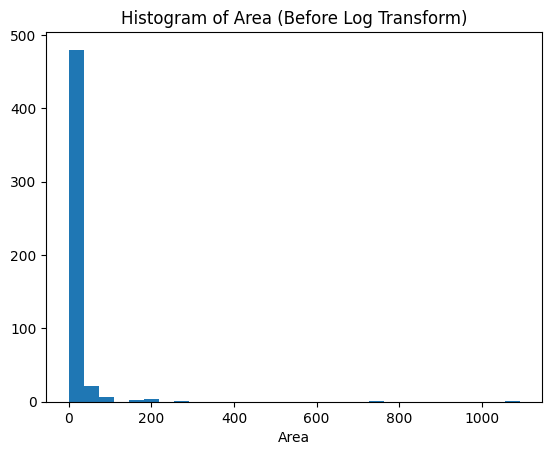

In [3]:
# ==========================================
# STEP 2: Histogram Before Log Transform
# ==========================================
plt.figure()
plt.hist(df["area"], bins=30)
plt.title("Histogram of Area (Before Log Transform)")
plt.xlabel("Area")
plt.show()

area ≈ 0 มี เกือบ 490 ตัวอย่าง แปลว่า ไฟไหม้เล็กมาก หรือไม่ลาม

แต่บางเหตุการณ์ใหญ่ผิดปกติ (Outliers) เช่น ในกราฟจะเห็นแท่งไกล ๆ เช่น
area ≈ 1090 <br>
ปัญหาที่จะเกิดกับ Machine Learning:
Linear Regression ชอบข้อมูลที่ประมาณ Normal Distribution <br>
แต่ dataset นี้เป็น Highly skewed distribution ผลคือ model เรียนรู้ยาก, prediction แย่

จึงต้อง ใช้ log เพื่อลดความต่างของ scale

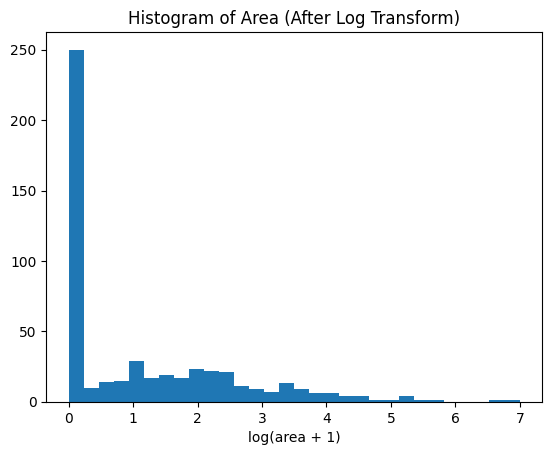

In [4]:
# ==========================================
# STEP 3: Log Transform
# ==========================================
df["area"] = np.log1p(df["area"])

# ==========================================
# STEP 4: Histogram After Log Transform
# ==========================================
plt.figure()
plt.hist(df["area"], bins=30)
plt.title("Histogram of Area (After Log Transform)")
plt.xlabel("log(area + 1)")
plt.show()

In [5]:
# dataframe Pre One-Hot Encoding
df

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.000000
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.000000
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.000000
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.000000
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
511,8,6,aug,sun,81.6,56.7,665.6,1.9,27.8,35,2.7,0.0,0.000000
512,4,3,aug,sun,81.6,56.7,665.6,1.9,27.8,32,2.7,0.0,2.006871
513,2,4,aug,sun,81.6,56.7,665.6,1.9,21.9,71,5.8,0.0,4.012592
514,7,4,aug,sun,81.6,56.7,665.6,1.9,21.2,70,6.7,0.0,2.498152


โมเดล ML เช่น scikit-learn ต้องการข้อมูลแบบ ตัวเลขเท่านั้น

จึงต้องมีการ Encodeing

In [6]:
# ==========================================
# STEP 5: One-Hot Encoding
# ==========================================
df = pd.get_dummies(df, columns=["month", "day"])

X = df.drop("area", axis=1)
y = df["area"]

features = X.columns

In [7]:
# dataframe After One-Hot Encoding
df

,X,Y,FFMC,DMC,DC,ISI,temp,RH,wind,rain,...,month_may,month_oct,month_sep,day_fri,day_mon,day_sat,day_sun,day_thu,day_tue,day_wed
0,7,5,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,...,False,False,False,True,False,False,False,False,False,False
1,7,4,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,...,False,True,False,False,False,False,False,False,True,False
2,7,4,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,...,False,True,False,False,False,True,False,False,False,False
3,8,6,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,...,False,False,False,True,False,False,False,False,False,False
4,8,6,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,...,False,False,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
511,8,6,81.6,56.7,665.6,1.9,27.8,35,2.7,0.0,...,False,False,False,False,False,False,True,False,False,False
512,4,3,81.6,56.7,665.6,1.9,27.8,32,2.7,0.0,...,False,False,False,False,False,False,True,False,False,False
513,2,4,81.6,56.7,665.6,1.9,21.9,71,5.8,0.0,...,False,False,False,False,False,False,True,False,False,False
514,7,4,81.6,56.7,665.6,1.9,21.2,70,6.7,0.0,...,False,False,False,False,False,False,True,False,False,False


จะเห็นได้ว่า มีจำนวนคอลัมม์มากขึ้น จาก 13 เป็น 29 คอลัมม์ เพราะใช้ One-hot Encoding

In [8]:
X

,X,Y,FFMC,DMC,DC,ISI,temp,RH,wind,rain,...,month_may,month_oct,month_sep,day_fri,day_mon,day_sat,day_sun,day_thu,day_tue,day_wed
0,7,5,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,...,False,False,False,True,False,False,False,False,False,False
1,7,4,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,...,False,True,False,False,False,False,False,False,True,False
2,7,4,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,...,False,True,False,False,False,True,False,False,False,False
3,8,6,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,...,False,False,False,True,False,False,False,False,False,False
4,8,6,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,...,False,False,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
511,8,6,81.6,56.7,665.6,1.9,27.8,35,2.7,0.0,...,False,False,False,False,False,False,True,False,False,False
512,4,3,81.6,56.7,665.6,1.9,27.8,32,2.7,0.0,...,False,False,False,False,False,False,True,False,False,False
513,2,4,81.6,56.7,665.6,1.9,21.9,71,5.8,0.0,...,False,False,False,False,False,False,True,False,False,False
514,7,4,81.6,56.7,665.6,1.9,21.2,70,6.7,0.0,...,False,False,False,False,False,False,True,False,False,False


dataframe X เหลือ 28 columns เพราะตัดเอา column "area" ออก

In [9]:
y

,area
0,0.000000
1,0.000000
2,0.000000
3,0.000000
4,0.000000
...,...
511,0.000000
512,2.006871
513,4.012592
514,2.498152


In [10]:
# ==========================================
# STEP 6: Train/Test Split
# ==========================================
X_cv, X_eval, y_cv, y_eval = train_test_split(
    X, y,
    test_size=0.10,
    random_state=42
)

STEP 7: Cross Validation ใช้ Pipeline + Cross Validation + Grid Search เพื่อหา model ที่ดีที่สุด

In [11]:
# ==========================================
# STEP 7: Cross Validation
# ==========================================
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LinearRegression())
])

param_grid = {
    "lr__fit_intercept": [True, False]
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=10,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

grid.fit(X_cv, y_cv)

best_model = grid.best_estimator_

print("\nBest parameters:", grid.best_params_)
print("Best CV RMSE:", -grid.best_score_)


Best parameters: {'lr__fit_intercept': True}
Best CV RMSE: 1.5294451779779


STEP 8 ประเมินผลโมเดลกับข้อมูลที่ไม่เคยเห็นมาก่อน (Test set) เพื่อดูว่าโมเดลที่ฝึกมา ทำนายได้ดีจริงไหม

In [12]:
# ==========================================
# STEP 8: Final Evaluation
# ==========================================
y_pred = best_model.predict(X_eval)

rmse = np.sqrt(mean_squared_error(y_eval, y_pred))
r2 = r2_score(y_eval, y_pred)

print("\nEvaluation RMSE:", rmse)
print("Evaluation R2:", r2)


Evaluation RMSE: 1.5698459391545831
Evaluation R2: -0.05860023233676981


STEP 9 ดึงโมเดลจริง ๆ ออกมาจาก Pipeline เพื่อดูค่าภายในของโมเดล เช่น coefficients และ intercept ของ Linear Regression

In [13]:
# ==========================================
# STEP 9: Extract Model
# ==========================================
scaler = best_model.named_steps["scaler"]
lr_model = best_model.named_steps["lr"]

coef = lr_model.coef_
intercept = lr_model.intercept_

STEP 10 สร้างสมการ Linear Regression ออกมาเป็นข้อความเพื่อให้อ่านโมเดลได้ง่าย

In [14]:
# ==========================================
# STEP 10: Regression Equation (Scaled)
# ==========================================
equation_scaled = f"y = {intercept:.4f}"

for c, f in zip(coef, features):
    sign = "+" if c >= 0 else "-"
    equation_scaled += f" {sign} {abs(c):.4f}*{f}"

print("\nRegression Equation (Scaled):")
print(equation_scaled)


Regression Equation (Scaled):
y = 1.1092 + 0.1116*X - 0.0140*Y + 0.0436*FFMC + 0.2491*DMC - 0.4109*DC - 0.0999*ISI + 0.2420*temp + 0.0547*RH + 0.0654*wind + 0.0154*rain - 0.0817*month_apr - 0.0566*month_aug + 0.2441*month_dec - 0.0158*month_feb - 0.0495*month_jan - 0.0754*month_jul - 0.1125*month_jun - 0.2027*month_mar + 0.1063*month_may + 0.0544*month_oct + 0.2095*month_sep - 0.0559*day_fri - 0.0100*day_mon + 0.0480*day_sat - 0.0163*day_sun - 0.0344*day_thu + 0.0608*day_tue + 0.0119*day_wed


STEP 11 แปลงสมการ Regression จาก “scaled features” กลับไปเป็น “original features” <br>
เพราะก่อนหน้านี้ใช้ StandardScaler ทำให้โมเดลเรียนรู้จาก ข้อมูลที่ถูก normalize แล้ว

In [15]:
# ==========================================
# STEP 11.1: Convert Equation to Original Scale
# ==========================================
means = scaler.mean_
stds = scaler.scale_

coef_original = coef / stds
intercept_original = intercept - np.sum(coef * means / stds)

equation_original = f"y = {intercept_original:.4f}"

for c, f in zip(coef_original, features):
    sign = "+" if c >= 0 else "-"
    equation_original += f" {sign} {abs(c):.4f}*{f}"

print("\nRegression Equation (Original Scale):")
print(equation_original)


Regression Equation (Original Scale):
y = -0.1859 + 0.0486*X - 0.0115*Y + 0.0076*FFMC + 0.0038*DMC - 0.0016*DC - 0.0218*ISI + 0.0414*temp + 0.0034*RH + 0.0370*wind + 0.0498*rain - 0.6276*month_apr - 0.1183*month_aug + 1.8753*month_dec - 0.0797*month_feb - 0.7559*month_jan - 0.3068*month_jul - 0.6363*month_jun - 0.6596*month_mar + 2.2923*month_may + 0.3074*month_oct + 0.4456*month_sep - 0.1536*day_fri - 0.0283*day_mon + 0.1303*day_sat - 0.0415*day_sun - 0.1080*day_thu + 0.1851*day_tue + 0.0388*day_wed


In [17]:
# ==========================================
# STEP 11.2: Analyze Coefficients
# ==========================================

increase_features = []
decrease_features = []

for c, f in zip(coef_original, features):
    if c > 0:
        increase_features.append((f, c))
    elif c < 0:
        decrease_features.append((f, c))

print("\nAttributes that increase forest fire area:")
for f, c in increase_features:
    print(f"{f}: {c:.4f}")

print("\nAttributes that decrease forest fire area:")
for f, c in decrease_features:
    print(f"{f}: {c:.4f}")


Attributes that increase forest fire area:
X: 0.0486
FFMC: 0.0076
DMC: 0.0038
temp: 0.0414
RH: 0.0034
wind: 0.0370
rain: 0.0498
month_dec: 1.8753
month_may: 2.2923
month_oct: 0.3074
month_sep: 0.4456
day_sat: 0.1303
day_tue: 0.1851
day_wed: 0.0388

Attributes that decrease forest fire area:
Y: -0.0115
DC: -0.0016
ISI: -0.0218
month_apr: -0.6276
month_aug: -0.1183
month_feb: -0.0797
month_jan: -0.7559
month_jul: -0.3068
month_jun: -0.6363
month_mar: -0.6596
day_fri: -0.1536
day_mon: -0.0283
day_sun: -0.0415
day_thu: -0.1080


In [18]:
# ==========================================
# STEP 11.3: Attributes with very small effect
# ==========================================

small_effect = []

for c, f in zip(coef_original, features):
    if abs(c) < 0.01:
        small_effect.append((f, c))

print("\nAttributes with very small effect (|coef| < 0.01):")
for f, c in small_effect:
    print(f"{f}: {c:.4f}")


Attributes with very small effect (|coef| < 0.01):
FFMC: 0.0076
DMC: 0.0038
DC: -0.0016
RH: 0.0034


STEP 12 เตรียมข้อมูลจาก dataset ภายนอก (external dataset) เพื่อเอาไป ทดสอบโมเดลที่ train ไว้แล้ว ว่าสามารถทำนายข้อมูลใหม่ได้ไหม <br>

โค้ดนี้จะทำ data preprocessing ให้เหมือนกับ training data ทุกอย่าง

In [41]:
# ==========================================
# STEP 12: External Dataset
# ==========================================
url_test = "https://raw.githubusercontent.com/kamonphankanthayod/ml-regression-predict-forest-fires/refs/heads/main/forestfires2.csv"

df_test = pd.read_csv(url_test)
df_test

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,6,3,nov,tue,79.5,3,106.7,1.1,11.8,31,4.5,0,0


In [42]:
df_test["area"] = np.log1p(df_test["area"])
df_test = pd.get_dummies(df_test, columns=["month", "day"])
df_test

,X,Y,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area,month_nov,day_tue
0,6,3,79.5,3,106.7,1.1,11.8,31,4.5,0,0.0,True,True


In [43]:
df_test = df_test.reindex(columns=df.columns, fill_value=0)
df_test

,X,Y,FFMC,DMC,DC,ISI,temp,RH,wind,rain,...,month_may,month_oct,month_sep,day_fri,day_mon,day_sat,day_sun,day_thu,day_tue,day_wed
0,6,3,79.5,3,106.7,1.1,11.8,31,4.5,0,...,0,0,0,0,0,0,0,0,True,0


In [44]:
X_test = df_test.drop("area", axis=1)
X_test

,X,Y,FFMC,DMC,DC,ISI,temp,RH,wind,rain,...,month_may,month_oct,month_sep,day_fri,day_mon,day_sat,day_sun,day_thu,day_tue,day_wed
0,6,3,79.5,3,106.7,1.1,11.8,31,4.5,0,...,0,0,0,0,0,0,0,0,True,0


In [46]:
x_external = X_test.iloc[[-1]]
print("\nExternal Observation:")
x_external


External Observation:


,X,Y,FFMC,DMC,DC,ISI,temp,RH,wind,rain,...,month_may,month_oct,month_sep,day_fri,day_mon,day_sat,day_sun,day_thu,day_tue,day_wed
0,6,3,79.5,3,106.7,1.1,11.8,31,4.5,0,...,0,0,0,0,0,0,0,0,True,0


In [47]:
# ==========================================
# STEP 13: Predict External Data
# ==========================================

y_external_log = best_model.predict(x_external)

y_external = np.expm1(y_external_log)

print("\nPredicted log(area):", y_external_log[0])
print("Predicted area:", y_external[0])


Predicted log(area): 1.4341851680668691
Predicted area: 3.196224397727771
